In [1]:
from envs.stowage_graph import StowageGraphEnv

config_dict = {
    "vessel_shape": (5, 1, 4),
    "yard_shape": (5, 1, 4),
    "num_containers": 20,
    "group_num": 3,
    "group_placement": "random",
    "seed": 4307,
}
env = StowageGraphEnv(config=config_dict)
observation, info = env.reset()


In [6]:
env._get_valid_yard_actions()

array([ 9, 11, 22, 24, 25, 26])

In [7]:
obs, reward, terminated, truncated, info = env.step(9)

In [17]:
env._get_valid_yard_actions

<bound method StowageEnv._get_valid_yard_actions of <envs.stowage_graph.StowageGraphEnv object at 0x7f3a11f27e10>>

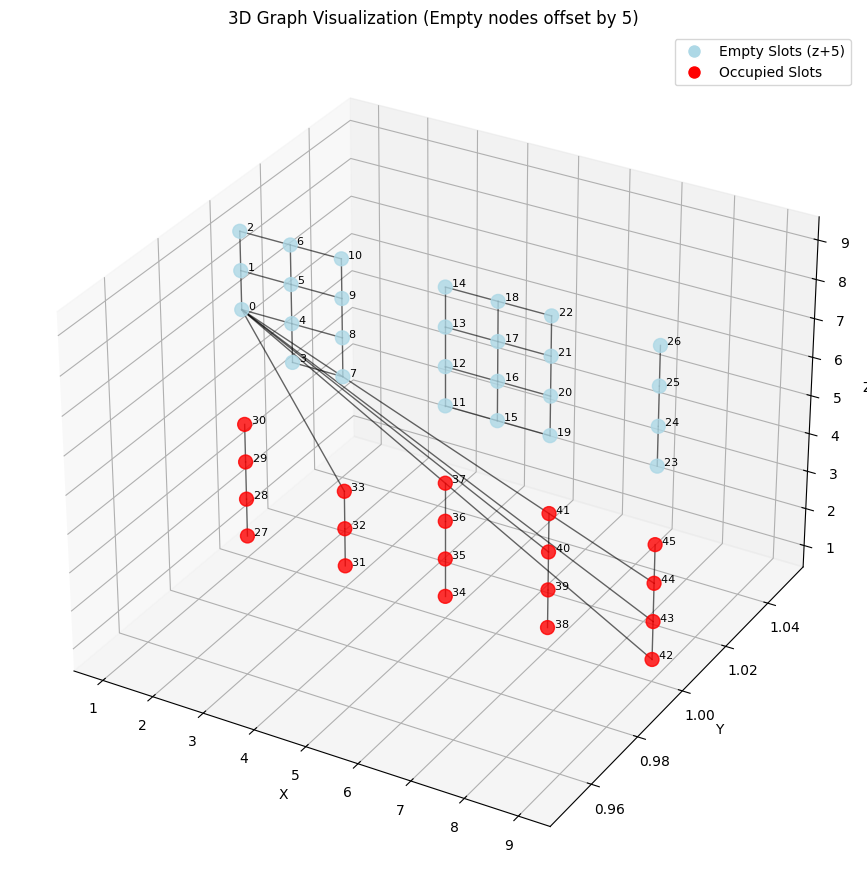

In [10]:
import matplotlib.pyplot as plt
import networkx as nx


def visualize_graph_3d(obs, z_offset=0.5):
    G = nx.Graph()

    nodes = obs.nodes
    pos_3d = {}

    for i, node in enumerate(nodes):
        x, y, z = node[0], node[1], node[2]

        # if the node represents an empty slot (4th column is 0), apply z offset
        if len(node) > 3 and node[3] == 0:
            z = z + z_offset

        G.add_node(i, x=x, y=y, z=z, features=node)
        pos_3d[i] = (x, y, z)

    edge_links = obs.edge_links
    for edge in edge_links:
        G.add_edge(edge[0], edge[1])

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    xs = [pos_3d[node][0] for node in G.nodes()]
    ys = [pos_3d[node][1] for node in G.nodes()]
    zs = [pos_3d[node][2] for node in G.nodes()]
    colors = []
    for node in nodes:
        if len(node) > 3:
            if node[3] == 0:
                colors.append("lightblue")
            else:
                colors.append("red")
        else:
            colors.append("blue")

    ax.scatter(xs, ys, zs, c=colors, s=100, alpha=0.8)

    for i, (x, y, z) in enumerate(zip(xs, ys, zs)):
        ax.text(x, y, z, f"  {i}", fontsize=8)

    for edge in G.edges():
        x_coords = [pos_3d[edge[0]][0], pos_3d[edge[1]][0]]
        y_coords = [pos_3d[edge[0]][1], pos_3d[edge[1]][1]]
        z_coords = [pos_3d[edge[0]][2], pos_3d[edge[1]][2]]
        ax.plot(x_coords, y_coords, z_coords, "k-", alpha=0.6, linewidth=1)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"3D Graph Visualization (Empty nodes offset by {z_offset})")

    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="lightblue",
            markersize=10,
            label=f"Empty Slots (z+{z_offset})",
        ),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=10, label="Occupied Slots"),
    ]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

    return G, pos_3d


G, positions = visualize_graph_3d(obs, z_offset=5)